**Dataset Overview**

The Liberty Mutual Fire Peril Loss Cost dataset contains 105,450 commercial insurance records and 302 variables. In addition, there are 292 numerical variables and 10 categorical variables and 1 is an identifier. The response variable is target and this represents the fire-peril loss cost.

The dataset is representative of a typical commercial insurance dataset because there is extreme skewness, heavy tails and a large number of zeros. This makes it a strong candidate for GLMs (Tweedie/Gamma) and tree-based ensemble models.

In [2]:
# ======================================================
# CIND820 - Keystone Project
# Data Analysis and Visualization: Fire Peril Loss Cost (Liberty Mutual Insurance)
# Author: Debra Allen 
# ======================================================

# Call Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# ======================================================
# Descriptive Statistics
# ======================================================

# Load the dataset
DATA_URL = "https://media.githubusercontent.com/media/uni-Deb7943/TMU-CIND820/refs/heads/main/liberty_train.csv?token=CATLW7WFHOMAGOQWDXWT2FTJYXV3M"
data = pd.read_csv(DATA_URL, low_memory=False)

# Display the shape of the dataset
print("Dataset Shape:", data.shape)

# Display the first few rows of the dataset
print("\nFirst few rows of the dataset:")
data.head()

Dataset Shape: (452061, 302)

First few rows of the dataset:


,id,target,var1,var2,var3,var4,var5,var6,var7,var8,...,weatherVar227,weatherVar228,weatherVar229,weatherVar230,weatherVar231,weatherVar232,weatherVar233,weatherVar234,weatherVar235,weatherVar236
0,1,0.0,Z,Z,Z,N1,Z,Z,3,1,...,0.170351,0.0,0.00000,0.000000,1.117353,1.215303,0.112556,2.355737,0.404655,0.138667
1,2,0.0,Z,Z,Z,C1,Z,Z,3,2,...,0.266173,0.0,27.50823,0.000000,3.828979,1.036739,0.033052,0.856632,0.231232,0.742199
2,3,0.0,3,Z,4,J3,B,B,2,4,...,0.979517,0.0,0.00000,0.456134,0.098790,1.076535,0.566352,0.696013,0.693695,0.070654
3,4,0.0,3,Z,4,H1,B,Z,3,4,...,0.308761,0.0,0.00000,4.349042,0.401975,0.340631,0.290147,0.000000,0.000000,0.090332
4,5,0.0,Z,Z,Z,H1,Z,Z,2,4,...,2.171972,0.0,0.00000,0.514990,0.516095,1.016120,1.313732,1.338487,2.948202,0.816485


In [5]:
# Reduce the size of the Train dataset to 25 % as the memory is being fully exhausted
# The rows are selected randomly

train = data.sample(frac = .25, replace = False)

In [6]:
# Display basic structure of the dataset
print("\nDataset Info:")
train.info()

# Display the shape of the reduced dataset
print("\nDataset Shape:", train.shape)


Dataset Info:
<class 'pandas.DataFrame'>
Index: 113015 entries, 309368 to 331556
Columns: 302 entries, id to weatherVar236
dtypes: float64(291), int64(1), str(10)
memory usage: 261.3 MB

Dataset Shape: (113015, 302)


In [7]:
# Display summary statistics of the dataset
print("\nSummary Statistics:")
train.describe()


Summary Statistics:


,id,target,var10,var11,var12,var13,var14,var15,var16,var17,...,weatherVar227,weatherVar228,weatherVar229,weatherVar230,weatherVar231,weatherVar232,weatherVar233,weatherVar234,weatherVar235,weatherVar236
count,113015.000000,113015.000000,113015.000000,113015.000000,24270.000000,113015.000000,40388.000000,88298.000000,22558.000000,113015.000000,...,108148.000000,108148.000000,108148.000000,108148.000000,108148.000000,108148.000000,108148.000000,108148.000000,108148.000000,108148.000000
mean,451267.893501,0.007463,4.128448,1315.077532,3.097097,1.303169,0.224587,31.107460,73.464625,68.709904,...,0.948258,0.773212,1.005727,0.967238,1.007994,1.012494,0.895524,1.074558,0.994219,1.039441
std,261257.193208,0.225304,0.310572,1080.602759,0.291999,0.815343,0.429650,25.164336,43.285913,37.207240,...,0.732901,28.588353,3.836488,1.867188,3.362661,0.183579,1.080881,0.911979,1.371221,4.647895
min,4.000000,0.000000,3.742477,500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.010647,0.000000,0.000000,0.000000,0.000000,0.000000,0.001047,0.000000,0.000000,0.000000
25%,224302.500000,0.000000,3.898949,681.696413,2.934707,0.832555,0.000000,13.000000,10.000000,50.000000,...,0.415230,0.000000,0.000000,0.000000,0.069835,0.907250,0.250188,0.374776,0.231232,0.030243
50%,451359.000000,0.000000,4.039930,939.946807,3.094347,1.394959,0.000000,26.000000,100.000000,85.955056,...,0.787872,0.000000,0.000000,0.334218,0.200987,1.060658,0.746745,0.856632,0.578079,0.120323
75%,677994.500000,0.000000,4.314082,1494.657151,3.273289,1.939381,0.000000,42.000000,100.000000,100.000000,...,1.288277,0.000000,0.000000,1.366301,0.669390,1.134062,1.230880,1.552645,1.213965,0.397380
max,902779.000000,15.036644,5.554304,14104.377710,3.915716,2.894981,2.168059,342.500000,100.000000,100.000000,...,3.641247,3778.103919,171.926438,55.553810,137.327164,1.546449,50.053757,5.353948,8.093103,100.087491


In [8]:
# Display the data types of the columns in the dataset
print("\nData Types of Columns:")
train.dtypes


Data Types of Columns:


id                 int64
target           float64
var1                 str
var2                 str
var3                 str
                  ...   
weatherVar232    float64
weatherVar233    float64
weatherVar234    float64
weatherVar235    float64
weatherVar236    float64
Length: 302, dtype: object

In [9]:
# Compute mean, median, standard deviation, max, min and zero-rate 
# of the target variable only in both the reduced and full datasets

if 'target' in train.columns:
    print('Mean Loss Cost - Reduced Dataset:', train['target'].mean())
    print('Median - Reduced Dataset:', train['target'].median())
    print('Standard Deviation - Reduced Dataset:', train['target'].std())
    print('Max - Reduced Dataset:', train['target'].max())
    print('Min - Reduced Dataset:', train['target'].min())
    perc_zero = (train['target'] == 0).mean() * 100
    print('Zero-rate - Reduced Dataset: {:.4f}%'.format(perc_zero))
else:
    print('train target column not found')

if 'target' in data.columns:
    print('\nMean Loss Cost - Full Dataset:', data['target'].mean())
    print('Median - Full Dataset:', data['target'].median())
    print('Standard Deviation - Full Dataset:', data['target'].std())
    print('Max - Full Dataset:', data['target'].max())
    print('Min - Full Dataset:', data['target'].min())
    perc_zero = (data['target'] == 0).mean() * 100
    print('Zero-rate - Full Dataset: {:.4f}%'.format(perc_zero))
else:
    print('data target column not found')

Mean Loss Cost - Reduced Dataset: 0.007463141977958678
Median - Reduced Dataset: 0.0
Standard Deviation - Reduced Dataset: 0.22530380390273985
Max - Reduced Dataset: 15.03664357
Min - Reduced Dataset: 0.0
Zero-rate - Reduced Dataset: 99.7345%

Mean Loss Cost - Full Dataset: 0.007234069647007815
Median - Full Dataset: 0.0
Standard Deviation - Full Dataset: 0.21968841298549557
Max - Full Dataset: 25.92013792
Min - Full Dataset: 0.0
Zero-rate - Full Dataset: 99.7372%


In [10]:
# Separate Variable types
categorical_cols = train.select_dtypes(include=['object']).columns
numerical_cols = train.select_dtypes(include=['number']).columns

print("\nCategorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# Display the number of categorical and numerical columns
print("\nNumber of Categorical Columns:", len(categorical_cols))
print("Number of Numerical Columns:", len(numerical_cols))


Categorical Columns: Index(['var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var7', 'var8', 'var9',
       'dummy'],
      dtype='str')
Numerical Columns: Index(['id', 'target', 'var10', 'var11', 'var12', 'var13', 'var14', 'var15',
       'var16', 'var17',
       ...
       'weatherVar227', 'weatherVar228', 'weatherVar229', 'weatherVar230',
       'weatherVar231', 'weatherVar232', 'weatherVar233', 'weatherVar234',
       'weatherVar235', 'weatherVar236'],
      dtype='str', length=292)

Number of Categorical Columns: 10
Number of Numerical Columns: 292


C:\Users\uni_f\AppData\Local\Temp\ipykernel_35164\4156532869.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object']).columns


In [11]:
# Display summary statistics for numerical columns
describe_numerical = train[numerical_cols].describe().T
print("\nSummary Statistics for Numerical Columns:")
print(describe_numerical)

# Determine skewness and kurtosis for the numerical columns
skewness_train = train[numerical_cols].skew()
kurtosis_train = train[numerical_cols].kurtosis()

print("\nSkewness for Numerical Columns:")
print(skewness_train)

print("\nKurtosis for Numerical Columns:")
print(kurtosis_train)


Summary Statistics for Numerical Columns:
                  count           mean            std         min  \
id             113015.0  451267.893501  261257.193208    4.000000   
target         113015.0       0.007463       0.225304    0.000000   
var10          113015.0       4.128448       0.310572    3.742477   
var11          113015.0    1315.077532    1080.602759  500.000000   
var12           24270.0       3.097097       0.291999    0.000000   
...                 ...            ...            ...         ...   
weatherVar232  108148.0       1.012494       0.183579    0.000000   
weatherVar233  108148.0       0.895524       1.080881    0.001047   
weatherVar234  108148.0       1.074558       0.911979    0.000000   
weatherVar235  108148.0       0.994219       1.371221    0.000000   
weatherVar236  108148.0       1.039441       4.647895    0.000000   

                         25%            50%            75%            max  
id             224302.500000  451359.000000  677994.

*The 'target' variable is dominated by zero values:*

Mean loss cost: approx 0.007
Median: 0
Maximum observed loss cost: 25.9
Approximately 99.7% of observations have zero loss cost
Skewness: approx 46
Kurtosis: > 2300

This confirms that the most policies have no losses at all, but when a loss occurs it can sometimes be very large. This means that the loss cost must be modeled using a distribution that combines a spike at zero with a separate distribution that allows for rare, extreme losses.

**Descriptive Statistics Interpretation**

The descriptive statistics indicates that the fire-peril loss cost is extremely sparse and heavily right-skewed. The target variable has a median of 0 and more than 99% of the observations report no losses. The skewness and kurtosis values are very high and this confirms that there are rare, but large losses. 

Raw histogram of target variable shows extreme spike at zero.


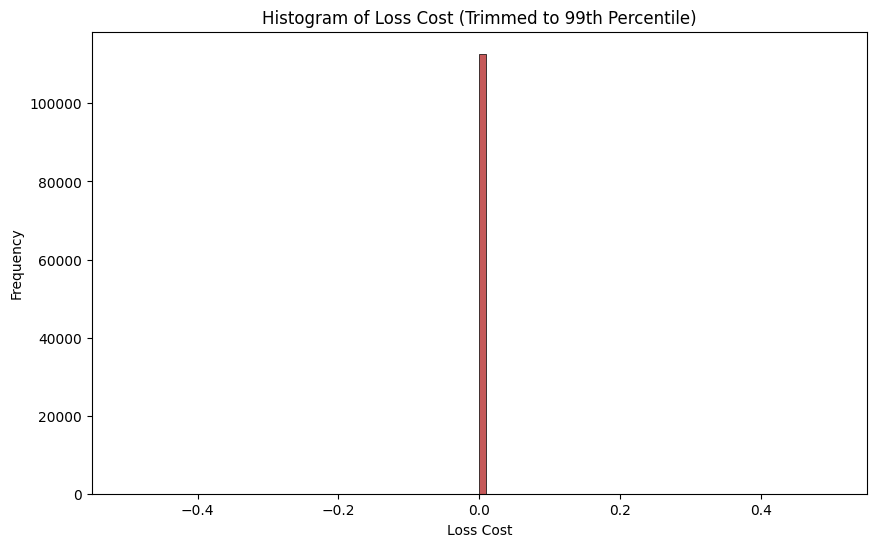

In [12]:
# ======================================================
# Visualization of the Target Variable
# ======================================================

# Plot histogram of target variable, trimmed to 99th percentile to remove extreme tail
print("Raw histogram of target variable shows extreme spike at zero.")

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(train['target'][train['target'] <= train['target'].quantile(0.99)], bins=100, color='firebrick')
plt.title('Histogram of Loss Cost (Trimmed to 99th Percentile)')
plt.xlabel('Loss Cost')
plt.ylabel('Frequency')
plt.show()

Log-transformed histogram of loss cost (positive losses only) shows a long right tail.


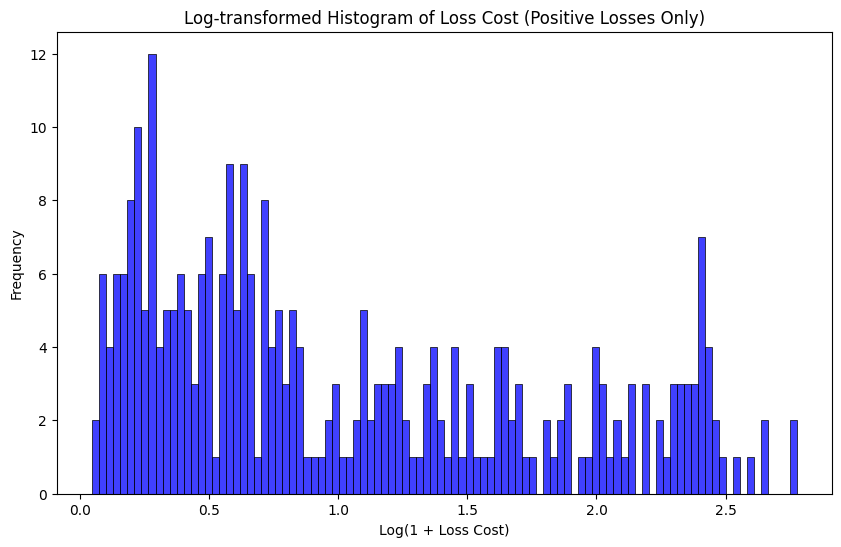

In [13]:
# Log-transformed histogram of target variable - positive losses only
print("Log-transformed histogram of loss cost (positive losses only) shows a long right tail.")

# Determine positive losses only
positive_losses = train.loc[train['target'] > 0, 'target']

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(positive_losses), bins=100, color='blue')
plt.title('Log-transformed Histogram of Loss Cost (Positive Losses Only)')
plt.xlabel('Log(1 + Loss Cost)')
plt.ylabel('Frequency')
plt.show()


Missing Values Count for Each Column:
var16        90457
var12        88745
var14        72627
crimeVar7    29469
crimeVar2    28771
             ...  
var3             0
var2             0
var1             0
target           0
id               0
Length: 302, dtype: int64

Top 20 Variables with the Most Missing Values:
var16            90457
var12            88745
var14            72627
crimeVar7        29469
crimeVar2        28771
crimeVar4        28301
crimeVar5        27766
crimeVar9        27603
crimeVar6        27603
crimeVar1        27603
crimeVar8        27603
crimeVar3        27603
var15            24717
weatherVar225     8157
weatherVar226     8157
weatherVar212     8157
weatherVar224     8157
weatherVar213     8157
weatherVar220     8157
weatherVar216     8157
dtype: int64


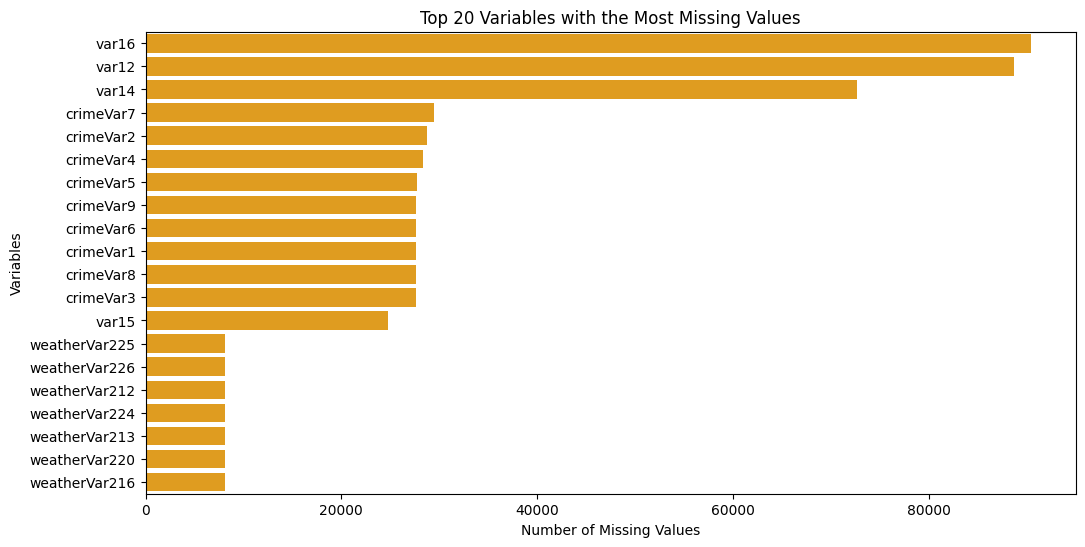

In [14]:
# ======================================================
# Missing Data Analysis
# ======================================================

# Count number of missing values
missing_counts = train.isnull().sum().sort_values(ascending=False)
print("\nMissing Values Count for Each Column:")
print(missing_counts)

# Top 20 variables with the most missing values
print("\nTop 20 Variables with the Most Missing Values:")
print(missing_counts.head(20))

# Bar plot of missing values for top 20 variables
plt.figure(figsize=(12, 6))
sns.barplot(y=missing_counts.head(20).index, x=missing_counts.head(20).values, color='orange')
plt.title('Top 20 Variables with the Most Missing Values')
plt.ylabel('Variables')
plt.xlabel('Number of Missing Values')
plt.show()


Correlation Matrix for Numerical Columns:
                     id    target     var10     var11     var12     var13  \
id             1.000000  0.003110  0.000108 -0.004202 -0.004684 -0.003395   
target         0.003110  1.000000 -0.009842 -0.005463  0.002498 -0.012957   
var10          0.000108 -0.009842  1.000000  0.230045 -0.067723  0.666705   
var11         -0.004202 -0.005463  0.230045  1.000000  0.551572  0.123233   
var12         -0.004684  0.002498 -0.067723  0.551572  1.000000 -0.301519   
...                 ...       ...       ...       ...       ...       ...   
weatherVar232 -0.000110 -0.000837 -0.108269 -0.024853 -0.011538 -0.123090   
weatherVar233 -0.000904 -0.000023  0.047125  0.042421  0.000274  0.038024   
weatherVar234  0.004877 -0.000073 -0.040167 -0.027861  0.002905 -0.065792   
weatherVar235  0.003901  0.003192  0.029702  0.008031  0.019312 -0.004001   
weatherVar236  0.006526  0.003462  0.016516  0.001986  0.026398  0.009084   

                  var14     var1

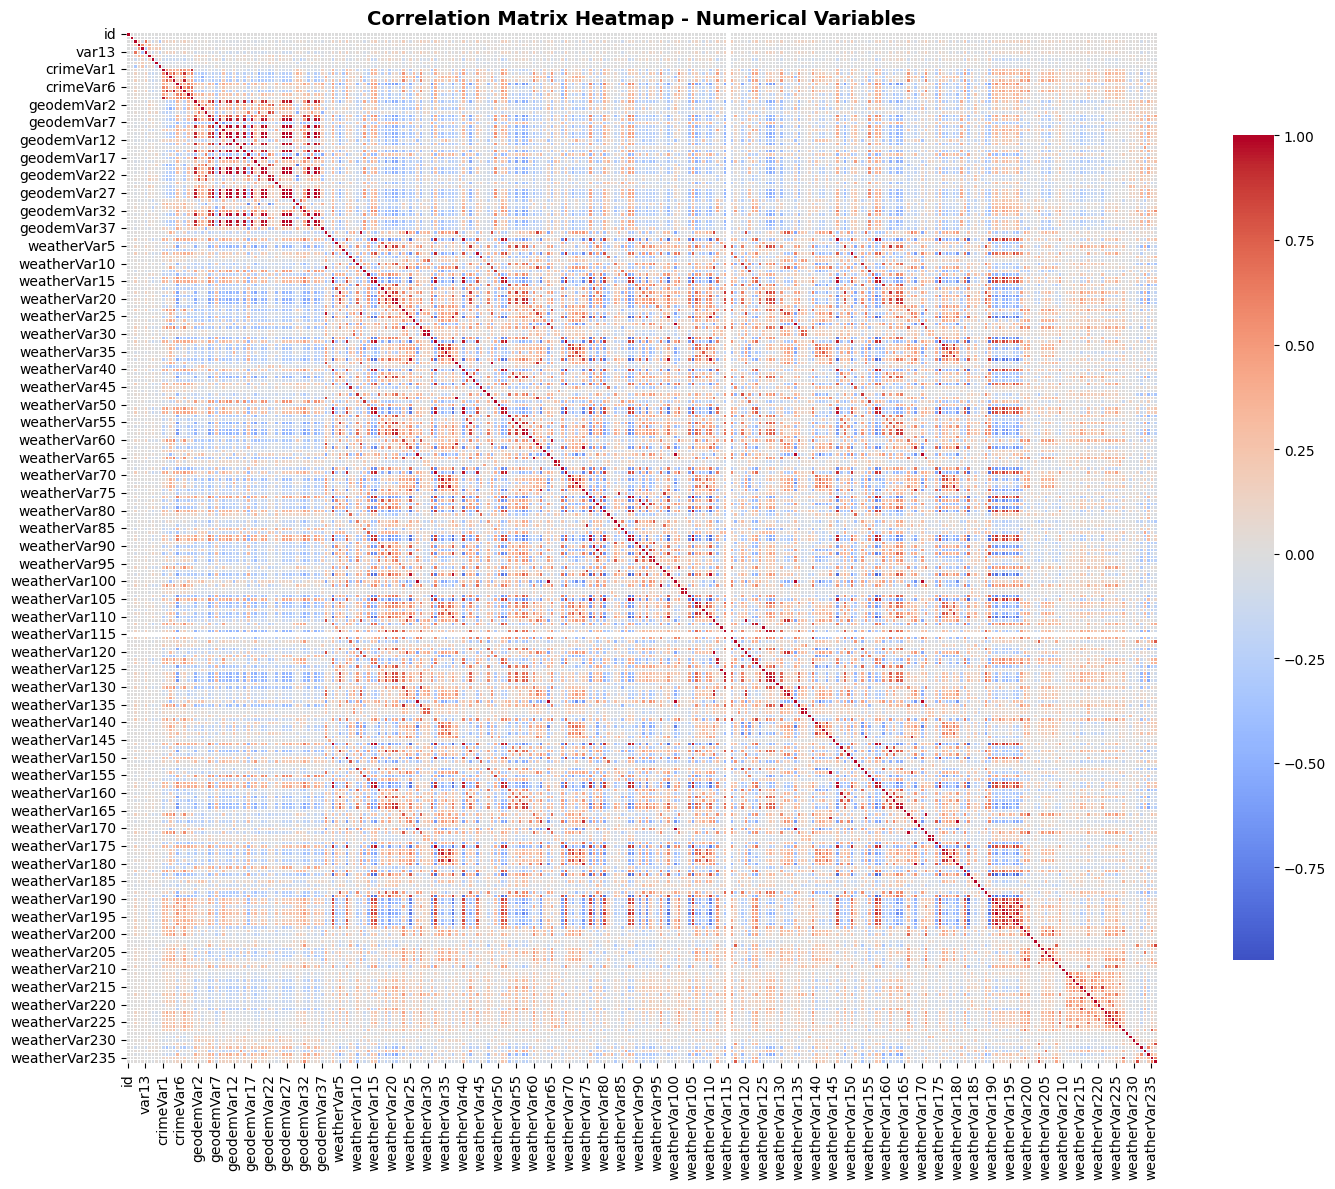


Correlation with Target Variable (sorted):
target           1.000000
crimeVar6        0.008802
crimeVar1        0.008384
crimeVar9        0.008209
weatherVar118    0.007832
                   ...   
var14           -0.008830
var10           -0.009842
var13           -0.012957
var16           -0.022456
weatherVar115         NaN
Name: target, Length: 292, dtype: float64


C:\Users\uni_f\AppData\Local\Temp\ipykernel_35164\1109745122.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


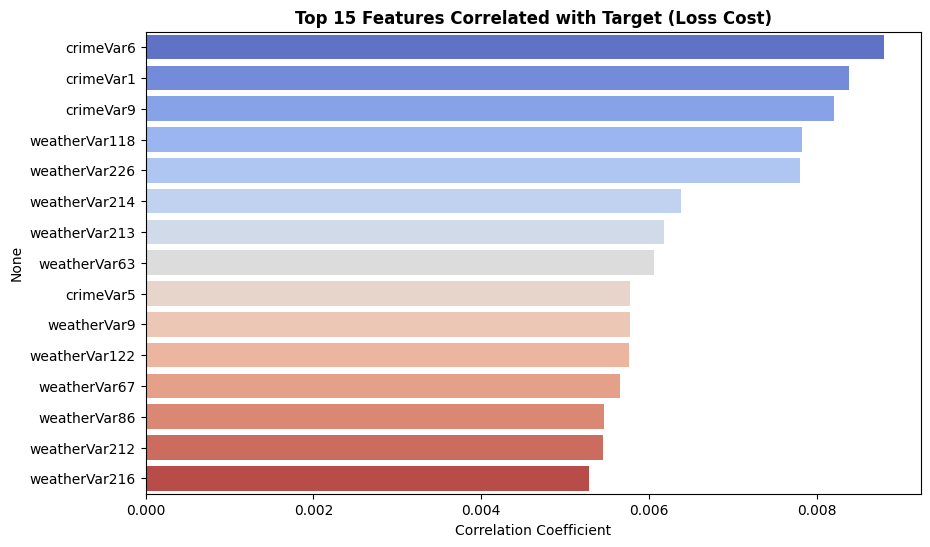

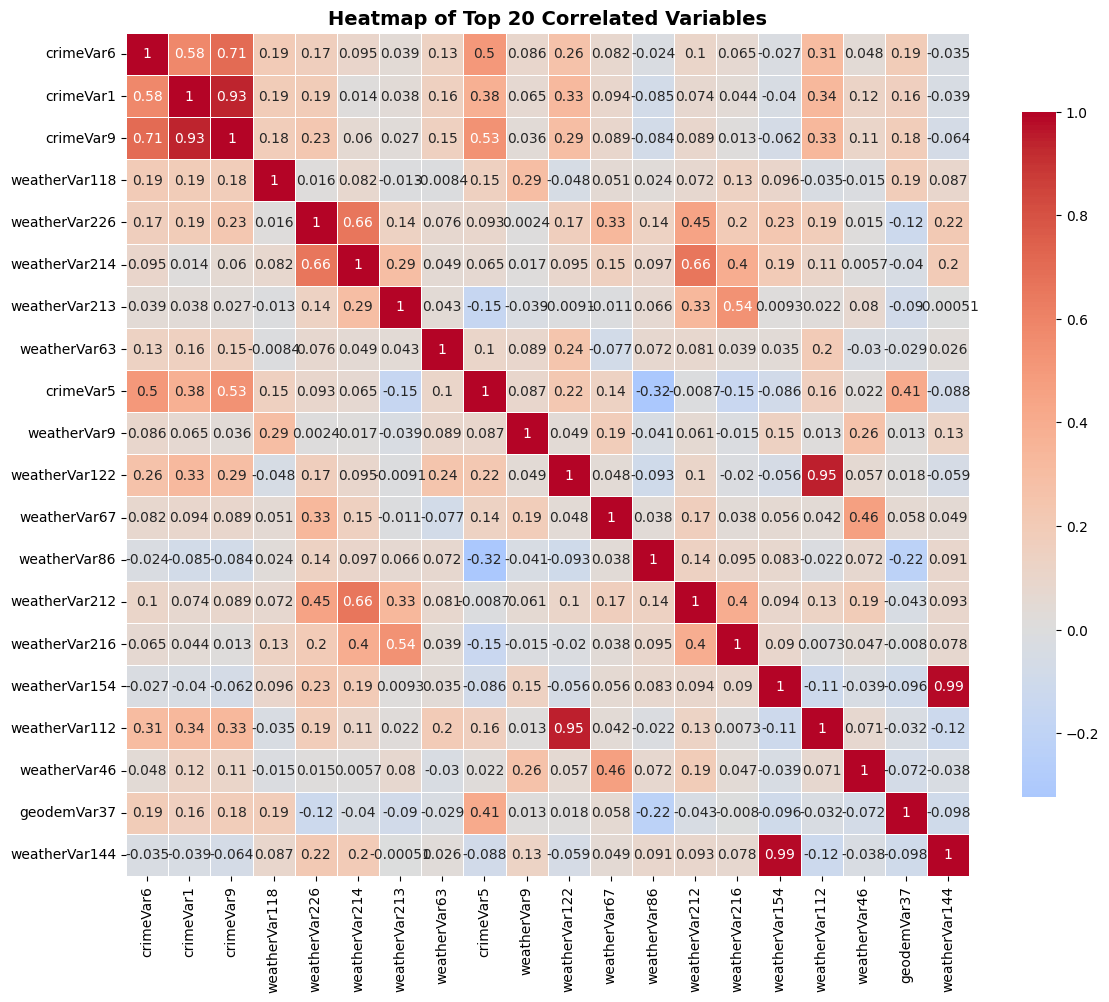

In [15]:
# =======================================================
# Correlation Analysis
# =======================================================

# Compute correlation matrix for loss cost and numerical variables
correlation_matrix = train[numerical_cols].corr()

print("\nCorrelation Matrix for Numerical Columns:")
print(correlation_matrix)

# Visualize correlation matrix with heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target variable
if 'target' in train.columns:
    target_corr = correlation_matrix['target'].sort_values(ascending=False)
    print("\nCorrelation with Target Variable (sorted):")
    print(target_corr)
    
    # Plot top 15 features correlated with target
    plt.figure(figsize=(10, 6))
    top_corr = target_corr[1:16]  # Exclude target itself
    sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
    plt.title('Top 15 Features Correlated with Target (Loss Cost)', fontsize=12, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.show()

# Heatmap of top 20 correlated variables
top_corr_vars = target_corr[1:21].index  # Exclude target itself
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix.loc[top_corr_vars, top_corr_vars], annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Heatmap of Top 20 Correlated Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


The Pearson correlations between predictors and the target variable are uniformly weak. This shows that claims are rare.

The top correlated variables weather, crime and geodemographic indicators.


Top 3 Features Most Correlated with Target Variable:
Index(['crimeVar6', 'crimeVar1', 'crimeVar9'], dtype='str')


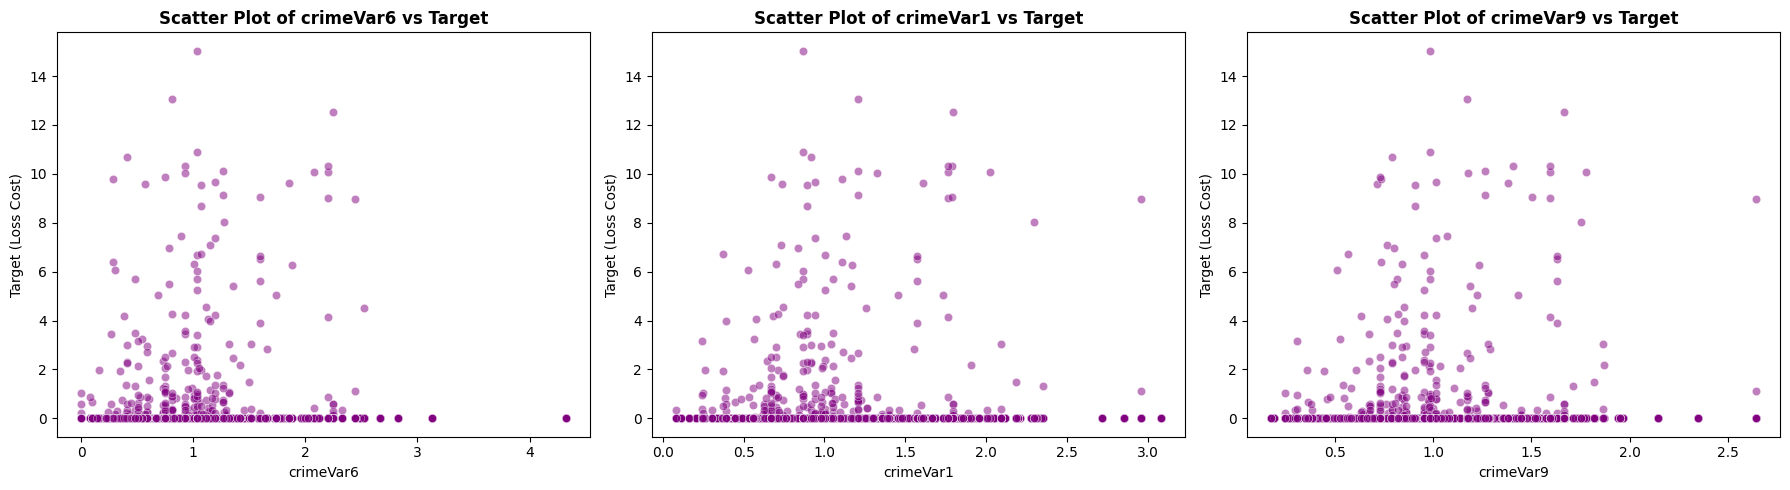

In [16]:
# =======================================================
# Scatter Plots of Top Correlated Variables with Target
# =======================================================

# Top 3 features most correlated with target variable
top3 = target_corr[1:4].index  # Exclude target itself
print("\nTop 3 Features Most Correlated with Target Variable:")
print(top3)

# Scatter plots of top 3 features with target variable
plt.figure(figsize=(18, 5))
for i, feature in enumerate(top3):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=train[feature], y=train['target'], alpha=0.5, color='purple')
    plt.title(f'Scatter Plot of {feature} vs Target', fontsize=12, fontweight='bold')
    plt.xlabel(feature)
    plt.ylabel('Target (Loss Cost)')
plt.tight_layout()
plt.show()


The scatter plots of the top 3 correlated predictors confirm that the relationships are non-linear.

**Insights on Correlation between Predictors and Target Variable (Loss Cost)**

The fire-peril lost cost data has very many zeros, with nearly all observations equal to zero and a small number of extreme positive losses. The correlations between the predictors and loss cost are uniformly weak. The suggests that linear effects alone are not sufficient. This means that Tweedie GLMs and gradient boosting methods will have to be used.